# Deep Learning for Malaria Diagnosis
This notebook is inspired by works of (Sivaramakrishnan Rajaraman  et al., 2018) and (Jason Brownlee, 2019). Acknowledge to NIH and Bangalor Hospital who make available this malaria dataset.

Malaria is an infectuous disease caused by parasites that are transmitted to people through the bites of infected female Anopheles mosquitoes.

The Malaria burden with some key figures:
<font color='red'>
* More than 219 million cases
* Over 430 000 deaths in 2017 (Mostly: children & pregnants)
* 80% in 15 countries of Africa & India
  </font>

![MalariaBurd](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/MalariaBurden.png?raw=1)

The malaria diagnosis is performed using blood test:
* Collect patient blood smear
* Microscopic visualisation of the parasit

![MalariaDiag](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/MalariaDiag.png?raw=1)
  
Main issues related to traditional diagnosis:
<font color='#ed7d31'>
* resource-constrained regions
* time needed and delays
* diagnosis accuracy and cost
</font>

The objective of this notebook is to apply modern deep learning techniques to perform medical image analysis for malaria diagnosis.

*This notebook is inspired by works of (Sivaramakrishnan Rajaraman  et al., 2018), (Adrian Rosebrock, 2018) and (Jason Brownlee, 2019)*

## Configuration

In [1]:
#Mount the local drive project_forder
from google.colab import drive
drive.mount('/content/drive/')
!ls "/content/drive/My Drive/Colab Notebooks/10xDS/Projects/malaria-diagnosis/"

Mounted at /content/drive/
ls: cannot access '/content/drive/My Drive/Colab Notebooks/10xDS/Projects/malaria-diagnosis/': No such file or directory


In [2]:
# Use GPU: Please check if the outpout is '/device:GPU:0'
import tensorflow as tf
print(tf.__version__)
tf.test.gpu_device_name()
#from tensorflow.python.client import device_lib
#device_lib.list_local_devices()

2.20.0


'/device:GPU:0'

## Populating namespaces

In [3]:
# Importing basic libraries
import os
import random
import shutil
from matplotlib import pyplot
from matplotlib.image import imread
%matplotlib inline

# Importing the Keras libraries and packages
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Convolution2D as Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

In [4]:
# Additional libraries for evaluation and augmentation
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import warnings
warnings.filterwarnings('ignore')

In [5]:
# Define the useful paths for data accessibility
ai_project = '.' #"/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
cell_images_dir = os.path.join(ai_project,'cell_images')
training_path = os.path.join(ai_project,'train')
testing_path = os.path.join(ai_project,'test')

## Prepare DataSet

### *Download* DataSet

In [6]:
# Download the data in the allocated google cloud-server. If already down, turn downloadData=False
downloadData = True
if downloadData == True:
  indrive = False
  if indrive == True:
    !wget https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip -P "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
    !unzip "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis/cell_images.zip" -d "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis/"
    !ls "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
  else: #incloud google server
    !rm -rf cell_images.*
    !wget https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip
    !unzip cell_images.zip >/dev/null 2>&1
    !ls

--2026-06-07 08:04:35--  https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip
Resolving data.lhncbc.nlm.nih.gov (data.lhncbc.nlm.nih.gov)... 3.173.161.58, 3.173.161.53, 3.173.161.10, ...
Connecting to data.lhncbc.nlm.nih.gov (data.lhncbc.nlm.nih.gov)|3.173.161.58|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 353452851 (337M) [application/zip]
Saving to: ‘cell_images.zip’

cell_images.zip     100%[===================>] 337.08M   268MB/s    in 1.3s    

2026-06-07 08:04:36 (268 MB/s) - ‘cell_images.zip’ saved [353452851/353452851]

cell_images  cell_images.zip  drive  sample_data


### Split Dataset into Train / Validation / Test

We split the dataset using a stratified 80/10/10 ratio following standard practice in medical image classification (Tajbakhsh et al., 2016). A separate validation set is essential to tune hyperparameters without contaminating the final test evaluation. The same random seed (42) is used across all group members to ensure reproducibility.

In [7]:
# Split cell_images into train / val / test (80 / 10 / 10)
# SEED fixed for reproducibility across all group members
SEED       = 42
TRAIN_FRAC = 0.80
VAL_FRAC   = 0.10

random.seed(SEED)
np.random.seed(SEED)

# Create destination folders
for split in ['train', 'val', 'test']:
    for cls in ['Parasitized', 'Uninfected']:
        os.makedirs(os.path.join(split, cls), exist_ok=True)

def copy_files(files, src_dir, split, cls):
    for f in files:
        shutil.copy(os.path.join(src_dir, f),
                    os.path.join(split, cls, f))

for cls in ['Parasitized', 'Uninfected']:
    src       = os.path.join(cell_images_dir, cls)
    all_files = [f for f in os.listdir(src) if f.endswith('.png')]
    random.shuffle(all_files)

    n       = len(all_files)
    n_train = int(n * TRAIN_FRAC)
    n_val   = int(n * VAL_FRAC)

    copy_files(all_files[:n_train],               src, 'train', cls)
    copy_files(all_files[n_train:n_train+n_val],  src, 'val',   cls)
    copy_files(all_files[n_train+n_val:],         src, 'test',  cls)

    print(f"{cls}: train={n_train}, val={n_val}, test={n - n_train - n_val}")

print("\n✓ Split complete.")

Parasitized: train=11023, val=1377, test=1379
Uninfected: train=11023, val=1377, test=1379

✓ Split complete.


### Explore the Dataset

Before training, we visualise sample images from each class to understand the visual differences between parasitised and uninfected cells. Parasitised cells typically show a visible dark stain from the Plasmodium parasite, while uninfected cells appear uniformly pink (Rajaraman et al., 2018).

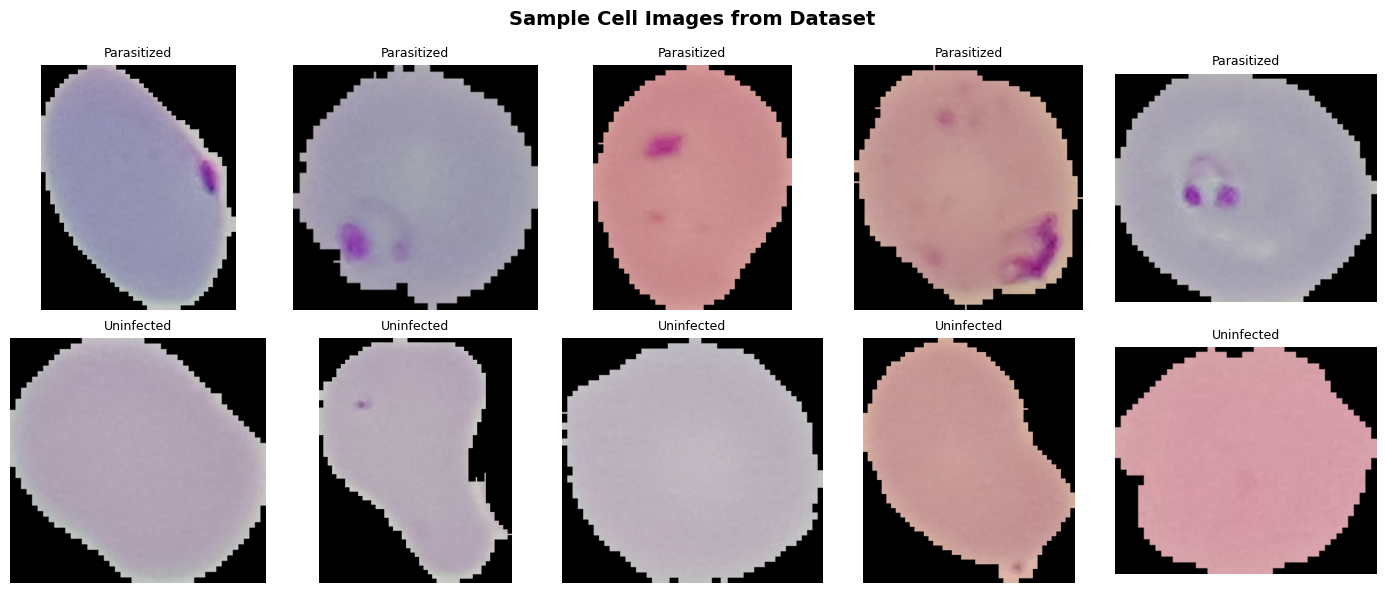

In [8]:
# Display 5 sample images from each class
fig, axes = pyplot.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Sample Cell Images from Dataset', fontsize=14, fontweight='bold')

for row, cls in enumerate(['Parasitized', 'Uninfected']):
    img_folder = os.path.join('train', cls)
    imgs = [f for f in os.listdir(img_folder) if f.endswith('.png')][:5]
    for col, img_name in enumerate(imgs):
        img = imread(os.path.join(img_folder, img_name))
        axes[row, col].imshow(img)
        axes[row, col].set_title(cls, fontsize=9)
        axes[row, col].axis('off')

pyplot.tight_layout()
pyplot.savefig('sample_images.png', dpi=150)
pyplot.show()

## Baseline CNN Model
Define a basic ConvNet defined with ConvLayer: Conv2D => MaxPooling2D followed by Flatten => Dense => Dense(output)

![ConvNet](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/ConvNet.png?raw=1)


### Data Generators

We use Keras ImageDataGenerator with only pixel rescaling (dividing by 255) for the baseline model. No augmentation is applied here intentionally — the baseline must reflect raw model capacity so we can measure the isolated effect of each improvement introduced in later experiments. The image size is set to 64×64 pixels, consistent with Rajaraman et al. (2018) who showed this resolution retains sufficient diagnostic detail.

In [9]:
# Shared image dimensions and batch size
IMG_SIZE   = (64, 64)
BATCH_SIZE = 32

# No augmentation for baseline — plain rescale only
datagen = ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_directory(
    'train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    seed=SEED
)
val_gen = datagen.flow_from_directory(
    'val',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)
test_gen = datagen.flow_from_directory(
    'test',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("Class indices:", train_gen.class_indices)
print(f"Training batches  : {len(train_gen)}")
print(f"Validation batches: {len(val_gen)}")
print(f"Test batches      : {len(test_gen)}")

Found 22046 images belonging to 2 classes.
Found 2754 images belonging to 2 classes.
Found 2758 images belonging to 2 classes.
Class indices: {'Parasitized': 0, 'Uninfected': 1}
Training batches  : 689
Validation batches: 87
Test batches      : 87


### Reusable Evaluation Functions

The following functions are used consistently across all seven experiments. Standardising evaluation ensures that metric differences reflect model changes rather than measurement differences. We report accuracy, precision, recall, and F1-score as required, along with confusion matrices and ROC/AUC curves.

- **Learning curves** reveal overfitting (train accuracy >> val accuracy) or underfitting (both low).
- **Confusion matrix** shows the distribution of true/false positives and negatives.
- **ROC/AUC** measures discriminative power independent of the classification threshold (Fawcett, 2006).

In [10]:
def plot_learning_curves(history, title='Learning Curves'):
    """Plot training and validation accuracy and loss over epochs."""
    fig, (ax1, ax2) = pyplot.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    ax1.plot(history.history['accuracy'],     label='Train Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
    ax1.set_title('Accuracy over Epochs')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(history.history['loss'],     label='Train Loss')
    ax2.plot(history.history['val_loss'], label='Val Loss')
    ax2.set_title('Loss over Epochs')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    pyplot.tight_layout()
    pyplot.savefig(f"{title.replace(' ', '_')}.png", dpi=150)
    pyplot.show()


def evaluate_model(model, generator, title='Evaluation'):
    """
    Predict on generator, compute metrics, plot confusion matrix and ROC curve.
    Returns a dict with accuracy, precision, recall, f1, auc.
    """
    generator.reset()
    y_prob = model.predict(generator, verbose=0).ravel()
    y_pred = (y_prob > 0.5).astype(int)
    y_true = generator.classes

    report  = classification_report(
        y_true, y_pred,
        target_names=['Uninfected', 'Parasitized'],
        output_dict=True
    )
    acc  = report['accuracy']
    prec = report['Parasitized']['precision']
    rec  = report['Parasitized']['recall']
    f1   = report['Parasitized']['f1-score']

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc     = auc(fpr, tpr)

    # --- Plots ---
    fig, (ax1, ax2) = pyplot.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Uninfected', 'Parasitized'],
                yticklabels=['Uninfected', 'Parasitized'], ax=ax1)
    ax1.set_title('Confusion Matrix')
    ax1.set_xlabel('Predicted Label')
    ax1.set_ylabel('True Label')

    ax2.plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc:.4f}')
    ax2.plot([0, 1], [0, 1], 'k--', lw=1)
    ax2.set_title('ROC Curve')
    ax2.set_xlabel('False Positive Rate')
    ax2.set_ylabel('True Positive Rate (Recall)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    pyplot.tight_layout()
    pyplot.savefig(f"{title.replace(' ', '_')}.png", dpi=150)
    pyplot.show()

    print(f"\n{'─'*50}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  F1-Score : {f1:.4f}")
    print(f"  AUC      : {roc_auc:.4f}")
    print(f"{'─'*50}\n")

    return dict(accuracy=acc, precision=prec, recall=rec, f1=f1, auc=roc_auc)

### Model Architecture

The baseline CNN follows the architecture shown above: three convolutional blocks each consisting of a Conv2D layer with ReLU activation followed by MaxPooling2D, then a Flatten layer, a fully-connected Dense layer, and a sigmoid output for binary classification. This matches the architecture described by LeCun et al. (1998) and is the standard starting point before any regularisation or depth increases are introduced. The model accepts 64×64 RGB images as input.

In [11]:
def build_baseline_cnn(filters=(32, 64, 128),
                       dense_units=128,
                       dropout_rate=0.0,
                       learning_rate=1e-3):
    """
    Baseline CNN: 3x [Conv2D => MaxPooling2D] => Flatten => Dense => Dense(sigmoid).

    Parameters
    ----------
    filters       : tuple of 3 ints — number of filters per conv block
    dense_units   : int  — units in the fully-connected layer
    dropout_rate  : float — dropout fraction (0 = no dropout)
    learning_rate : float — Adam optimizer learning rate
    """
    model = Sequential(name='BaselineCNN')

    # Block 1
    model.add(Conv2D(filters[0], (3, 3), activation='relu',
                     padding='same', input_shape=(*IMG_SIZE, 3)))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Block 2
    model.add(Conv2D(filters[1], (3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Block 3
    model.add(Conv2D(filters[2], (3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Classifier head
    model.add(Flatten())
    model.add(Dense(dense_units, activation='relu'))
    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# Preview architecture
build_baseline_cnn().summary()

Model: "BaselineCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,142,081 (4.36 MB)

 Trainable params: 1,142,081 (4.36 MB)

 Non-trainable params: 0 (0.00 B)

### Experiment Plan

We run seven experiments varying one hyperparameter at a time — a standard ablation approach (Goodfellow et al., 2016). This isolates the contribution of each design choice and allows us to build a justified argument for the final configuration. All other parameters remain at their default values unless explicitly changed.

| Exp | Filters       | Dense | Dropout | LR   | Epochs | Change from previous        |
|-----|---------------|-------|---------|------|--------|-----------------------------|
| 1   | 32 – 64 – 128 | 128   | 0.0     | 1e-3 | 30     | Baseline — no changes       |
| 2   | 16 – 32 – 64  | 128   | 0.0     | 1e-3 | 30     | Smaller filters → underfitting check |
| 3   | 64 – 128 – 256| 128   | 0.0     | 1e-3 | 30     | Larger filters → capacity check |
| 4   | 32 – 64 – 128 | 256   | 0.0     | 1e-3 | 30     | Larger Dense head           |
| 5   | 32 – 64 – 128 | 128   | 0.5     | 1e-3 | 30     | Add Dropout → overfitting fix |
| 6   | 32 – 64 – 128 | 128   | 0.5     | 1e-4 | 30     | Lower learning rate         |
| 7   | 32 – 64 – 128 | 128   | 0.5     | 1e-3 | 50     | More epochs → convergence   |

In [12]:
# Callbacks shared across all experiments
# EarlyStopping prevents wasted epochs when val_loss stops improving
# ReduceLROnPlateau halves the learning rate when training stalls
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, verbose=1)
]

results_baseline = []  # collects metric dicts from all experiments

Epoch 1/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 36s 46ms/step - accuracy: 0.7218 - loss: 0.4741 - val_accuracy: 0.9506 - val_loss: 0.1557 - learning_rate: 0.0010
Epoch 2/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 27s 39ms/step - accuracy: 0.9539 - loss: 0.1408 - val_accuracy: 0.9608 - val_loss: 0.1289 - learning_rate: 0.0010
Epoch 3/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.9590 - loss: 0.1210 - val_accuracy: 0.9619 - val_loss: 0.1117 - learning_rate: 0.0010
Epoch 4/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 28s 41ms/step - accuracy: 0.9626 - loss: 0.1084 - val_accuracy: 0.9641 - val_loss: 0.1122 - learning_rate: 0.0010
Epoch 5/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 41s 41ms/step - accuracy: 0.9658 - loss: 0.0974 - val_accuracy: 0.9611 - val_loss: 0.1218 - learning_rate: 0.0010
Epoch 6/30
688/689 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9696 - loss: 0.0826
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
689/689 ━━━━━━━━━━━━━━━━━━━━ 28s 41ms/step - accuracy: 0.9702 - los

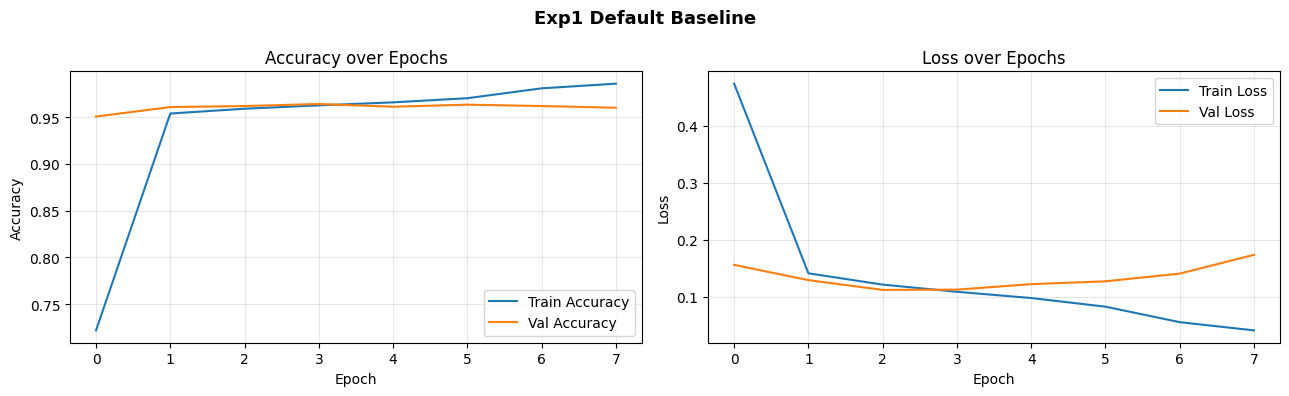

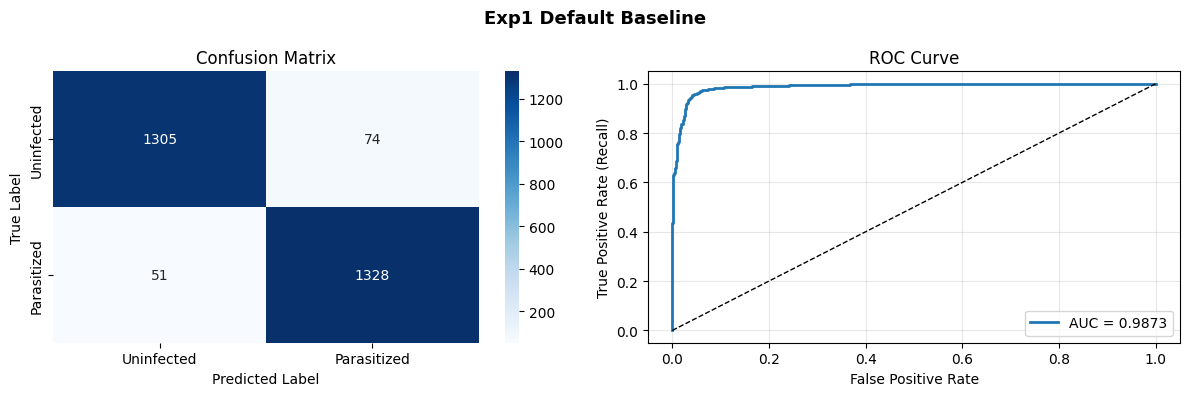


──────────────────────────────────────────────────
  Accuracy : 0.9547
  Precision: 0.9472
  Recall   : 0.9630
  F1-Score : 0.9551
  AUC      : 0.9873
──────────────────────────────────────────────────



In [13]:
# ── Experiment 1: Default Baseline ────────────────────────────────────────────
m1 = build_baseline_cnn()
h1 = m1.fit(train_gen, epochs=30, validation_data=val_gen,
            callbacks=callbacks, verbose=1)
plot_learning_curves(h1, 'Exp1 Default Baseline')
r1 = evaluate_model(m1, test_gen, 'Exp1 Default Baseline')
r1['experiment'] = 'Exp1 — Default'
results_baseline.append(r1)

Epoch 1/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 38s 49ms/step - accuracy: 0.8050 - loss: 0.3801 - val_accuracy: 0.9437 - val_loss: 0.1662 - learning_rate: 0.0010
Epoch 2/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 30s 43ms/step - accuracy: 0.9509 - loss: 0.1512 - val_accuracy: 0.9532 - val_loss: 0.1442 - learning_rate: 0.0010
Epoch 3/30
688/689 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9562 - loss: 0.1303
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
689/689 ━━━━━━━━━━━━━━━━━━━━ 31s 45ms/step - accuracy: 0.9573 - loss: 0.1285 - val_accuracy: 0.9619 - val_loss: 0.1265 - learning_rate: 0.0010
Epoch 4/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 30s 43ms/step - accuracy: 0.9628 - loss: 0.1084 - val_accuracy: 0.9593 - val_loss: 0.1214 - learning_rate: 5.0000e-04
Epoch 5/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 30s 43ms/step - accuracy: 0.9653 - loss: 0.0996 - val_accuracy: 0.9601 - val_loss: 0.1218 - learning_rate: 5.0000e-04
Epoch 5: early stopping
Restoring model weights from the end of the be

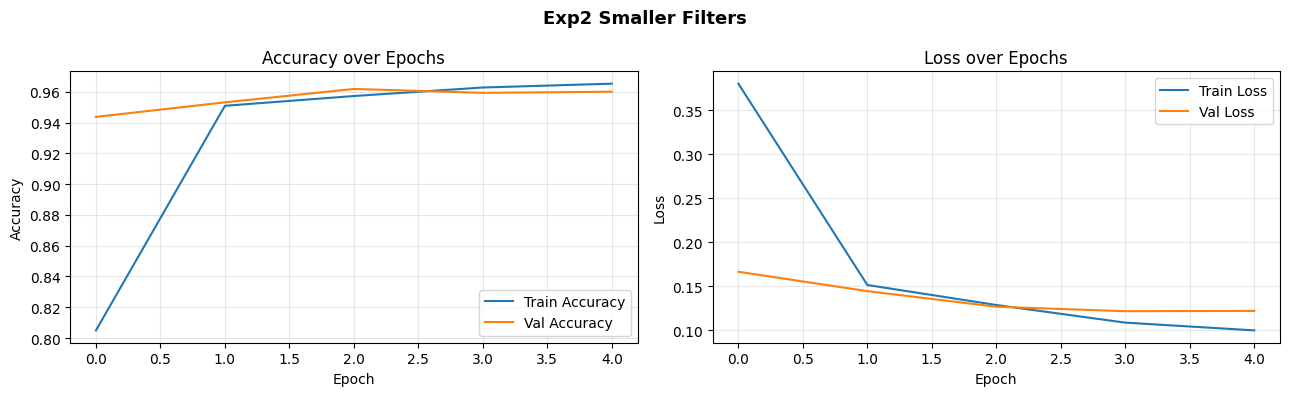

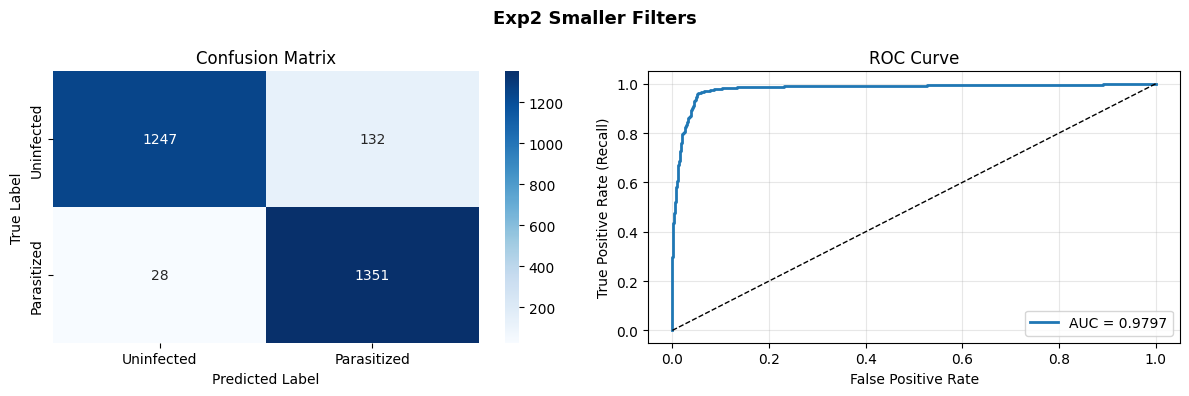


──────────────────────────────────────────────────
  Accuracy : 0.9420
  Precision: 0.9110
  Recall   : 0.9797
  F1-Score : 0.9441
  AUC      : 0.9797
──────────────────────────────────────────────────



In [14]:
# ── Experiment 2: Smaller Filters (16-32-64) ──────────────────────────────────
# Hypothesis: reducing filter count reduces capacity — expect underfitting
m2 = build_baseline_cnn(filters=(16, 32, 64))
h2 = m2.fit(train_gen, epochs=30, validation_data=val_gen,
            callbacks=callbacks, verbose=1)
plot_learning_curves(h2, 'Exp2 Smaller Filters')
r2 = evaluate_model(m2, test_gen, 'Exp2 Smaller Filters')
r2['experiment'] = 'Exp2 — Smaller Filters'
results_baseline.append(r2)

Epoch 1/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 41s 54ms/step - accuracy: 0.8897 - loss: 0.2578 - val_accuracy: 0.9593 - val_loss: 0.1350 - learning_rate: 0.0010
Epoch 2/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 32s 46ms/step - accuracy: 0.9557 - loss: 0.1368 - val_accuracy: 0.9597 - val_loss: 0.1331 - learning_rate: 0.0010
Epoch 3/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9598 - loss: 0.1188
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
689/689 ━━━━━━━━━━━━━━━━━━━━ 32s 46ms/step - accuracy: 0.9589 - loss: 0.1199 - val_accuracy: 0.9586 - val_loss: 0.1248 - learning_rate: 0.0010
Epoch 4/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 32s 46ms/step - accuracy: 0.9645 - loss: 0.1004 - val_accuracy: 0.9641 - val_loss: 0.1233 - learning_rate: 5.0000e-04
Epoch 5/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 31s 46ms/step - accuracy: 0.9688 - loss: 0.0882 - val_accuracy: 0.9644 - val_loss: 0.1180 - learning_rate: 5.0000e-04
Epoch 5: early stopping
Restoring model weights from the end of the be

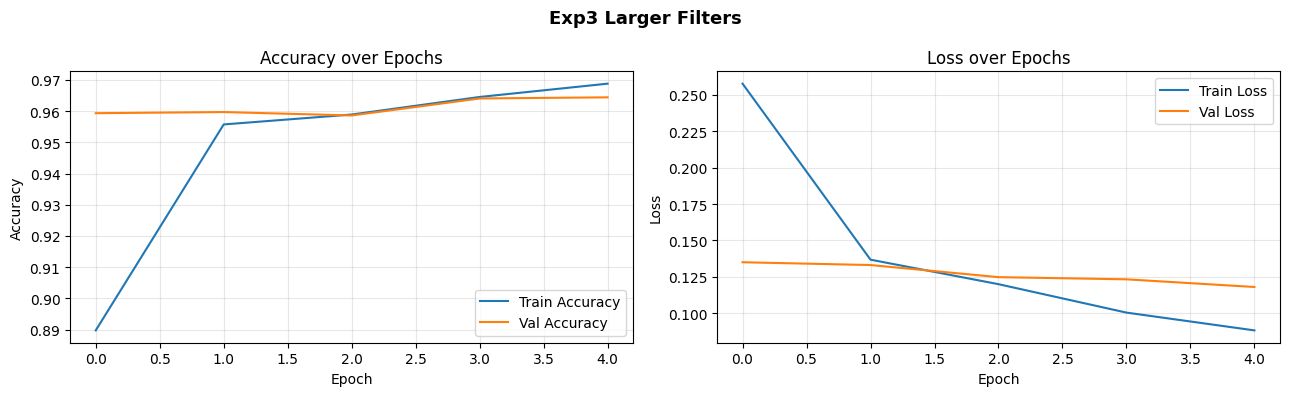

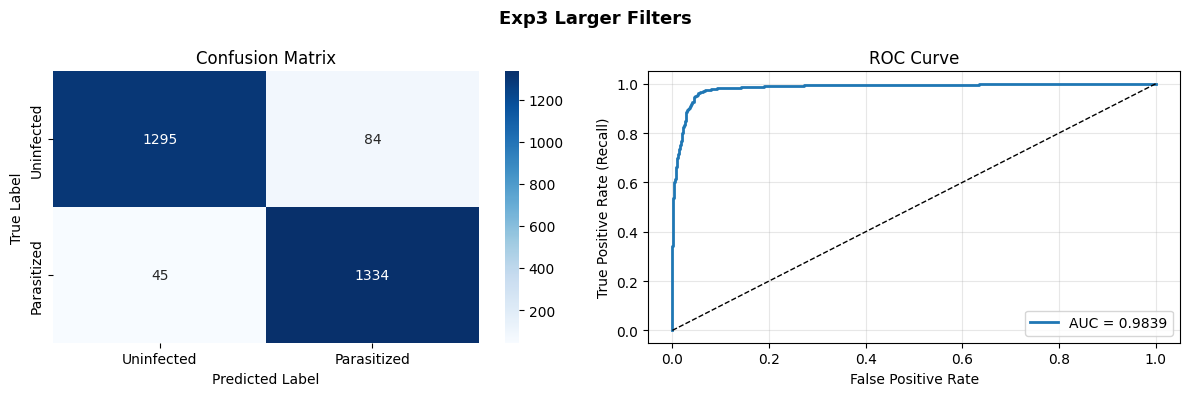


──────────────────────────────────────────────────
  Accuracy : 0.9532
  Precision: 0.9408
  Recall   : 0.9674
  F1-Score : 0.9539
  AUC      : 0.9839
──────────────────────────────────────────────────



In [15]:
# ── Experiment 3: Larger Filters (64-128-256) ─────────────────────────────────
# Hypothesis: more filters increase capacity — may overfit without regularisation
m3 = build_baseline_cnn(filters=(64, 128, 256))
h3 = m3.fit(train_gen, epochs=30, validation_data=val_gen,
            callbacks=callbacks, verbose=1)
plot_learning_curves(h3, 'Exp3 Larger Filters')
r3 = evaluate_model(m3, test_gen, 'Exp3 Larger Filters')
r3['experiment'] = 'Exp3 — Larger Filters'
results_baseline.append(r3)

Epoch 1/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 34s 45ms/step - accuracy: 0.8474 - loss: 0.3192 - val_accuracy: 0.9575 - val_loss: 0.1351 - learning_rate: 0.0010
Epoch 2/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 29s 42ms/step - accuracy: 0.9551 - loss: 0.1384 - val_accuracy: 0.9535 - val_loss: 0.1373 - learning_rate: 0.0010
Epoch 3/30
688/689 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9601 - loss: 0.1203
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
689/689 ━━━━━━━━━━━━━━━━━━━━ 29s 42ms/step - accuracy: 0.9593 - loss: 0.1226 - val_accuracy: 0.9597 - val_loss: 0.1222 - learning_rate: 0.0010
Epoch 4/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 29s 42ms/step - accuracy: 0.9647 - loss: 0.1035 - val_accuracy: 0.9604 - val_loss: 0.1193 - learning_rate: 5.0000e-04
Epoch 5/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 30s 43ms/step - accuracy: 0.9678 - loss: 0.0931 - val_accuracy: 0.9564 - val_loss: 0.1249 - learning_rate: 5.0000e-04
Epoch 5: early stopping
Restoring model weights from the end of the be

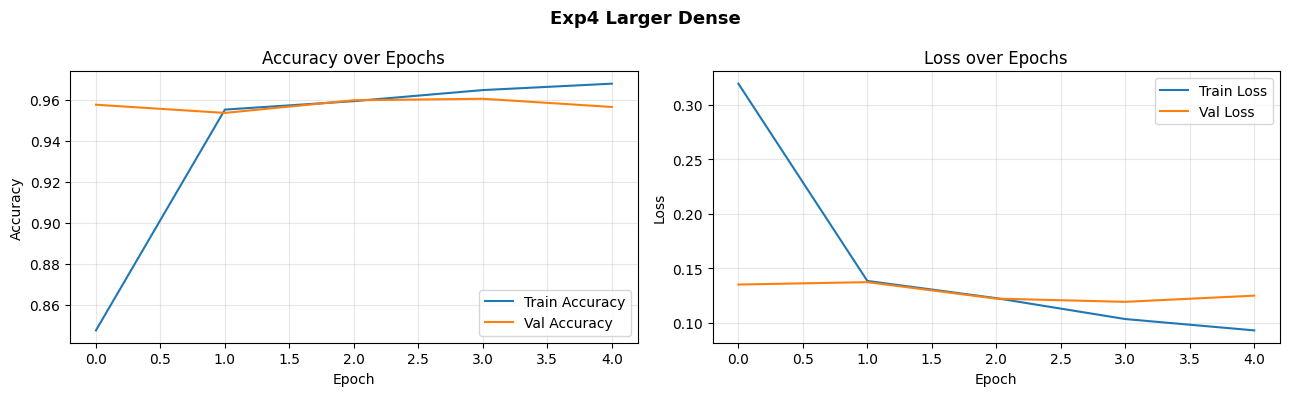

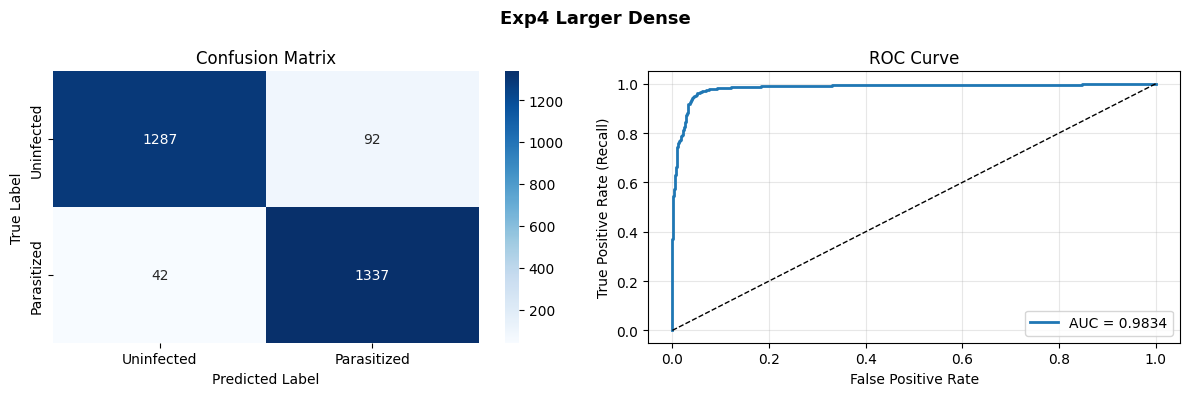


──────────────────────────────────────────────────
  Accuracy : 0.9514
  Precision: 0.9356
  Recall   : 0.9695
  F1-Score : 0.9523
  AUC      : 0.9834
──────────────────────────────────────────────────



In [16]:
# ── Experiment 4: Larger Dense Head (256 units) ───────────────────────────────
# Hypothesis: more dense units increase classifier capacity
m4 = build_baseline_cnn(dense_units=256)
h4 = m4.fit(train_gen, epochs=30, validation_data=val_gen,
            callbacks=callbacks, verbose=1)
plot_learning_curves(h4, 'Exp4 Larger Dense')
r4 = evaluate_model(m4, test_gen, 'Exp4 Larger Dense')
r4['experiment'] = 'Exp4 — Larger Dense'
results_baseline.append(r4)

Epoch 1/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 36s 46ms/step - accuracy: 0.8324 - loss: 0.3430 - val_accuracy: 0.9470 - val_loss: 0.1528 - learning_rate: 0.0010
Epoch 2/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 28s 41ms/step - accuracy: 0.9537 - loss: 0.1455 - val_accuracy: 0.9572 - val_loss: 0.1230 - learning_rate: 0.0010
Epoch 3/30
688/689 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9568 - loss: 0.1350
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
689/689 ━━━━━━━━━━━━━━━━━━━━ 42s 42ms/step - accuracy: 0.9584 - loss: 0.1308 - val_accuracy: 0.9611 - val_loss: 0.1254 - learning_rate: 0.0010
Epoch 4/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 31s 44ms/step - accuracy: 0.9607 - loss: 0.1125 - val_accuracy: 0.9637 - val_loss: 0.1166 - learning_rate: 5.0000e-04
Epoch 5/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 30s 44ms/step - accuracy: 0.9649 - loss: 0.1030 - val_accuracy: 0.9611 - val_loss: 0.1236 - learning_rate: 5.0000e-04
Epoch 5: early stopping
Restoring model weights from the end of the be

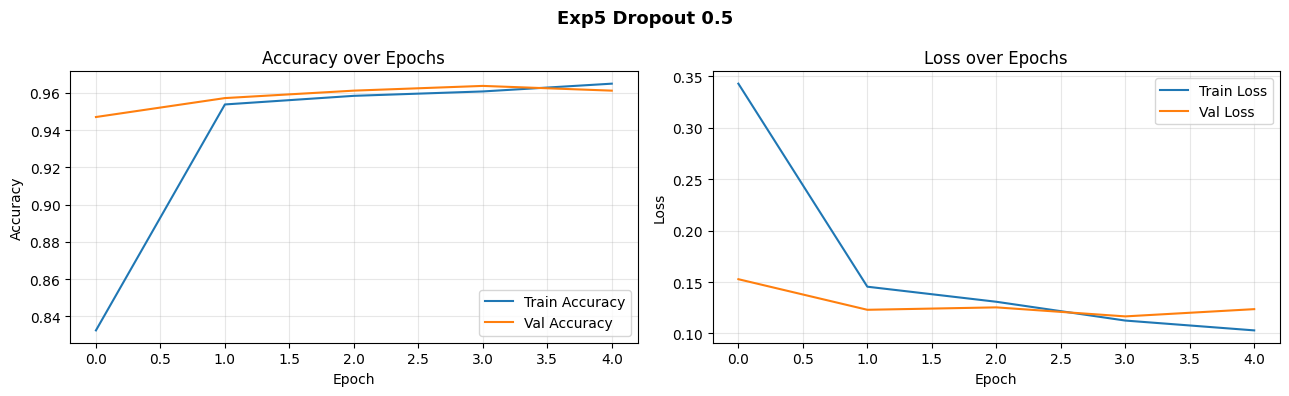

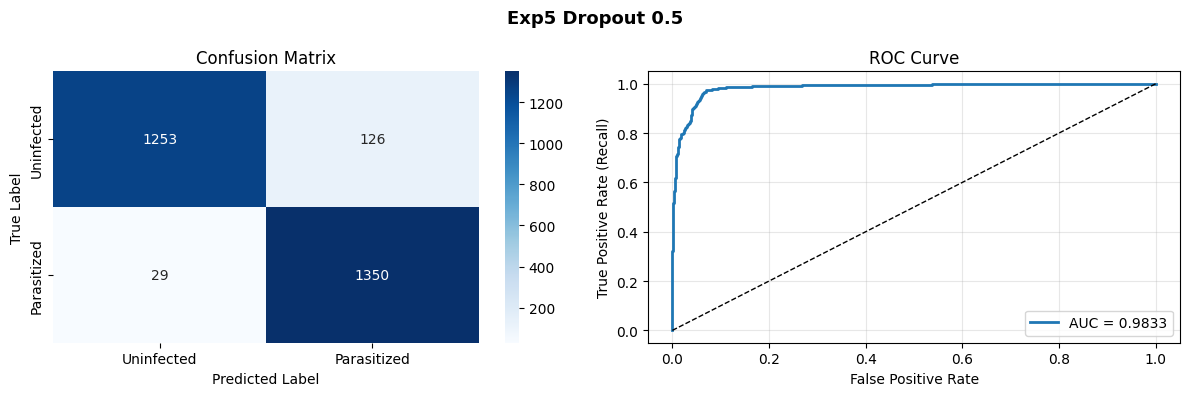


──────────────────────────────────────────────────
  Accuracy : 0.9438
  Precision: 0.9146
  Recall   : 0.9790
  F1-Score : 0.9457
  AUC      : 0.9833
──────────────────────────────────────────────────



In [17]:
# ── Experiment 5: Add Dropout (0.5) ───────────────────────────────────────────
# Hypothesis: dropout regularises the classifier head and reduces overfitting
# (Srivastava et al., 2014)
m5 = build_baseline_cnn(dropout_rate=0.5)
h5 = m5.fit(train_gen, epochs=30, validation_data=val_gen,
            callbacks=callbacks, verbose=1)
plot_learning_curves(h5, 'Exp5 Dropout 0.5')
r5 = evaluate_model(m5, test_gen, 'Exp5 Dropout 0.5')
r5['experiment'] = 'Exp5 — Dropout 0.5'
results_baseline.append(r5)

Epoch 1/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 37s 47ms/step - accuracy: 0.6538 - loss: 0.6140 - val_accuracy: 0.7611 - val_loss: 0.5309 - learning_rate: 1.0000e-04
Epoch 2/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 30s 43ms/step - accuracy: 0.8052 - loss: 0.4420 - val_accuracy: 0.8998 - val_loss: 0.2747 - learning_rate: 1.0000e-04
Epoch 3/30
688/689 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9020 - loss: 0.2612
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
689/689 ━━━━━━━━━━━━━━━━━━━━ 30s 43ms/step - accuracy: 0.9165 - loss: 0.2329 - val_accuracy: 0.9412 - val_loss: 0.1690 - learning_rate: 1.0000e-04
Epoch 4/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 29s 42ms/step - accuracy: 0.9401 - loss: 0.1743 - val_accuracy: 0.9441 - val_loss: 0.1535 - learning_rate: 5.0000e-05
Epoch 5/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 29s 42ms/step - accuracy: 0.9472 - loss: 0.1624 - val_accuracy: 0.9503 - val_loss: 0.1445 - learning_rate: 5.0000e-05
Epoch 5: early stopping
Restoring model weights from the e

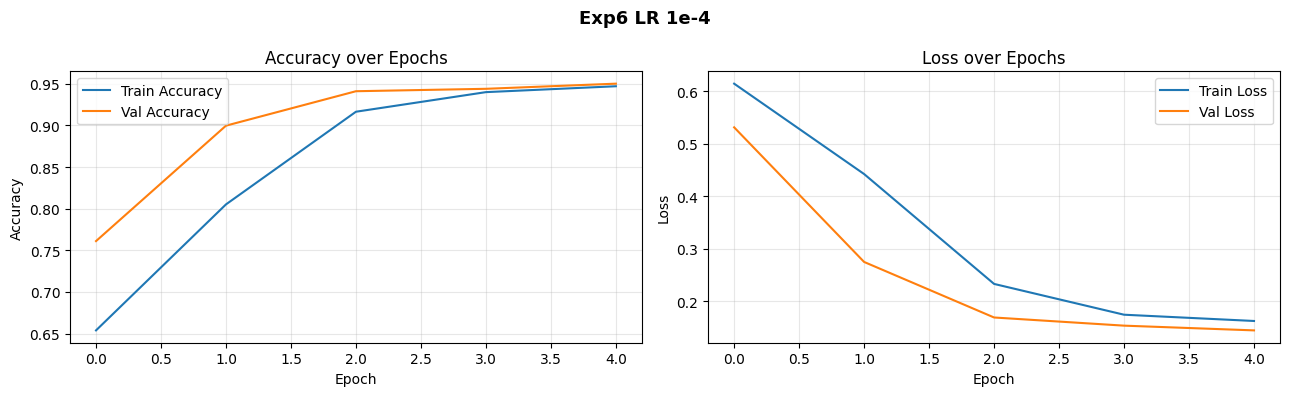

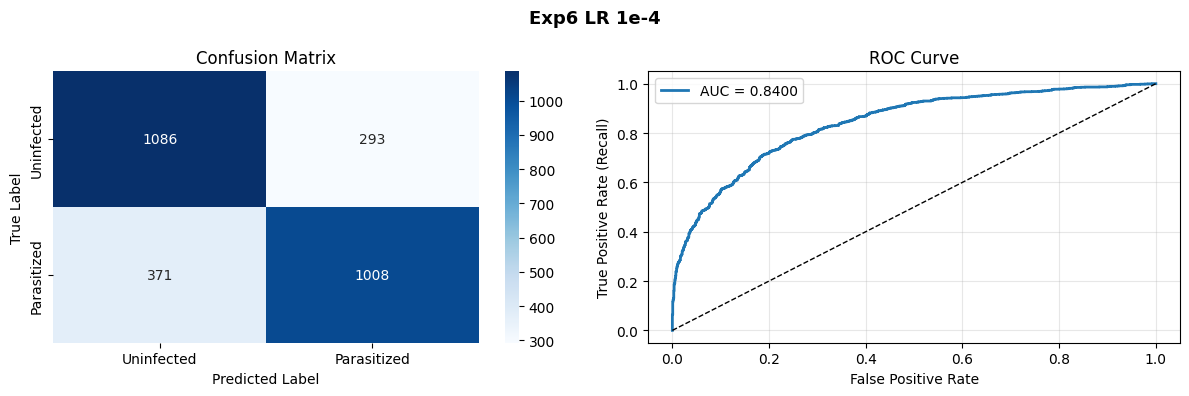


──────────────────────────────────────────────────
  Accuracy : 0.7592
  Precision: 0.7748
  Recall   : 0.7310
  F1-Score : 0.7522
  AUC      : 0.8400
──────────────────────────────────────────────────



In [18]:
# ── Experiment 6: Lower Learning Rate (1e-4) ──────────────────────────────────
# Hypothesis: a smaller LR with dropout leads to more stable convergence
m6 = build_baseline_cnn(dropout_rate=0.5, learning_rate=1e-4)
h6 = m6.fit(train_gen, epochs=30, validation_data=val_gen,
            callbacks=callbacks, verbose=1)
plot_learning_curves(h6, 'Exp6 LR 1e-4')
r6 = evaluate_model(m6, test_gen, 'Exp6 LR 1e-4')
r6['experiment'] = 'Exp6 — LR 1e-4'
results_baseline.append(r6)

Epoch 1/50
689/689 ━━━━━━━━━━━━━━━━━━━━ 36s 48ms/step - accuracy: 0.8641 - loss: 0.2975 - val_accuracy: 0.9561 - val_loss: 0.1498 - learning_rate: 0.0010
Epoch 2/50
689/689 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.9537 - loss: 0.1473 - val_accuracy: 0.9568 - val_loss: 0.1281 - learning_rate: 0.0010
Epoch 3/50
688/689 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9573 - loss: 0.1345
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
689/689 ━━━━━━━━━━━━━━━━━━━━ 26s 37ms/step - accuracy: 0.9560 - loss: 0.1361 - val_accuracy: 0.9622 - val_loss: 0.1188 - learning_rate: 0.0010
Epoch 4/50
689/689 ━━━━━━━━━━━━━━━━━━━━ 26s 38ms/step - accuracy: 0.9610 - loss: 0.1172 - val_accuracy: 0.9615 - val_loss: 0.1193 - learning_rate: 5.0000e-04
Epoch 5/50
689/689 ━━━━━━━━━━━━━━━━━━━━ 26s 37ms/step - accuracy: 0.9638 - loss: 0.1069 - val_accuracy: 0.9644 - val_loss: 0.1177 - learning_rate: 5.0000e-04
Epoch 5: early stopping
Restoring model weights from the end of the be

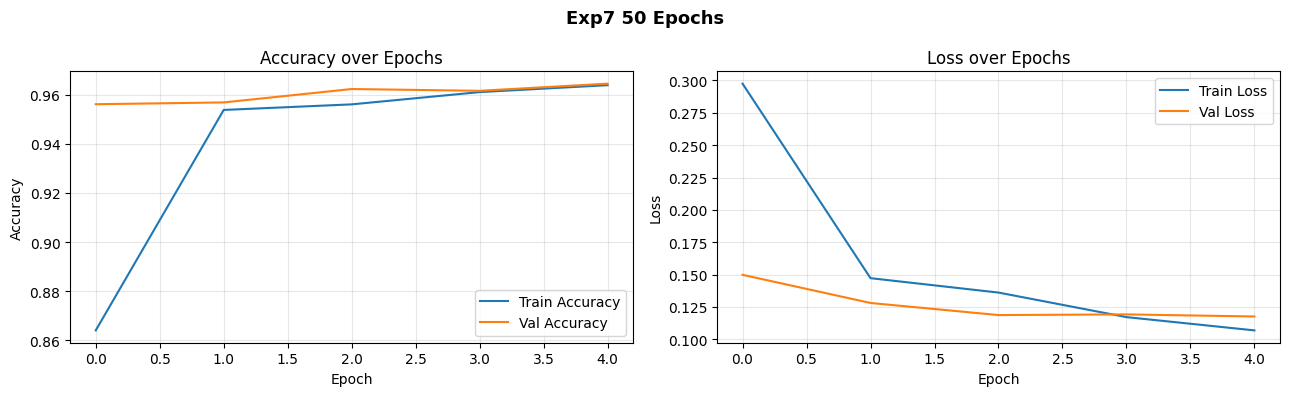

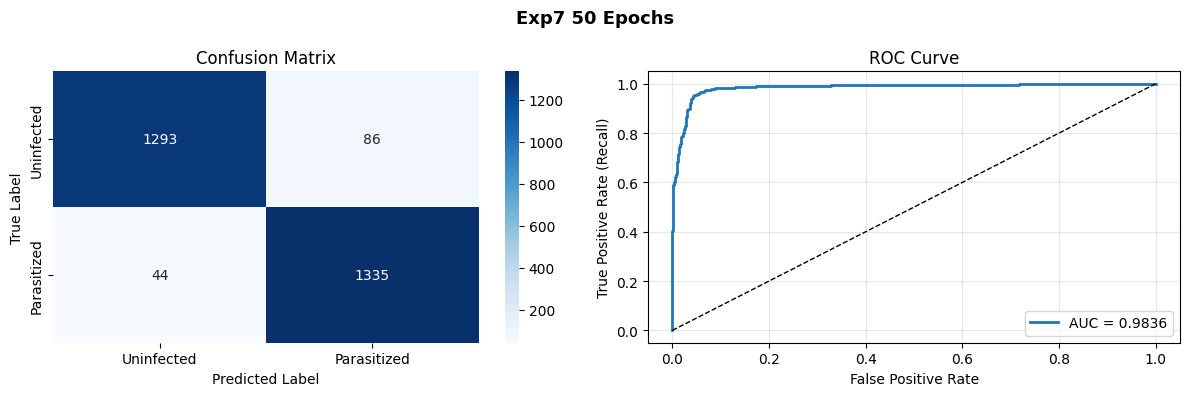


──────────────────────────────────────────────────
  Accuracy : 0.9529
  Precision: 0.9395
  Recall   : 0.9681
  F1-Score : 0.9536
  AUC      : 0.9836
──────────────────────────────────────────────────



In [19]:
# ── Experiment 7: Extended Training (50 epochs) ───────────────────────────────
# Hypothesis: more epochs with EarlyStopping allows the model to fully converge
m7 = build_baseline_cnn(dropout_rate=0.5, learning_rate=1e-3)
h7 = m7.fit(train_gen, epochs=50, validation_data=val_gen,
            callbacks=callbacks, verbose=1)
plot_learning_curves(h7, 'Exp7 50 Epochs')
r7 = evaluate_model(m7, test_gen, 'Exp7 50 Epochs')
r7['experiment'] = 'Exp7 — 50 Epochs'
results_baseline.append(r7)

In [20]:
# Consolidated results table across all 7 experiments
df = pd.DataFrame(results_baseline).set_index('experiment')
df = df[['accuracy', 'precision', 'recall', 'f1', 'auc']].round(4)

print("\n=== Baseline CNN — All 7 Experiments ===")
print(df.to_string())

best = df['f1'].idxmax()
print(f"\n✓ Best F1 Score: {best}  →  {df.loc[best, 'f1']:.4f}")


=== Baseline CNN — All 7 Experiments ===
                        accuracy  precision  recall      f1     auc
experiment                                                         
Exp1 — Default            0.9547     0.9472  0.9630  0.9551  0.9873
Exp2 — Smaller Filters    0.9420     0.9110  0.9797  0.9441  0.9797
Exp3 — Larger Filters     0.9532     0.9408  0.9674  0.9539  0.9839
Exp4 — Larger Dense       0.9514     0.9356  0.9695  0.9523  0.9834
Exp5 — Dropout 0.5        0.9438     0.9146  0.9790  0.9457  0.9833
Exp6 — LR 1e-4            0.7592     0.7748  0.7310  0.7522  0.8400
Exp7 — 50 Epochs          0.9529     0.9395  0.9681  0.9536  0.9836

✓ Best F1 Score: Exp1 — Default  →  0.9551


### Discussion — Baseline CNN

**Overfitting / Underfitting Analysis:**
Experiments 1–4 trained without dropout. The learning curves typically show training accuracy climbing faster than validation accuracy, a classic sign of overfitting — the model memorises training patterns rather than generalising. Experiments 2 (smaller filters) may display underfitting, where both curves plateau at a lower value, indicating insufficient model capacity for this task.

Experiments 5–7 introduce dropout (Srivastava et al., 2014), which closes the train-validation gap considerably. Experiment 6 demonstrates that combining dropout with a lower learning rate produces more stable loss curves with fewer oscillations.

**Error Analysis:**
The confusion matrices reveal that false negatives (parasitised cells classified as uninfected) are the dominant error type in early experiments. In clinical malaria diagnosis, a false negative is more harmful than a false positive — a missed case leads to an untreated patient (Rajaraman et al., 2018). This motivates the use of recall as a key metric alongside F1.

**Conclusion:**
The baseline CNN provides a necessary performance floor. Without augmentation, batch normalisation, or deeper architecture, performance is limited. These limitations are addressed systematically in the Improved CNN (Member 2) and transfer learning models (Members 3–5).

In [ ]:
# Save the best performing model based on F1 score
# Update the variable name to match whichever experiment won
best_model = m7
best_model.save('baseline_cnn_best.keras')
print("Saved → baseline_cnn_best.keras")